#  Telco Customer Churn — Exploratory Data Analysis (EDA)

## Goal
Explore the dataset, understand its structure, identify patterns and anomalies
before building a churn prediction model.

**Dataset:** Telco Customer Churn (Kaggle)  
**Target variable:** `Churn` — whether the customer left the service (Yes/No)

## 1. Imports & Configuration

In [ ]:
# imports and configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="ticks")
%matplotlib inline

## 2. Load Data

In [6]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. First Look at the Data

In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Missing Values

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values:")
print(missing)

Missing values:
Series([], dtype: int64)


In [9]:
# TotalCharges is stored as object — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with 0 (new customers with 0 tenure)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing values after fix:")
print(df.isnull().sum().sum())

Missing values after fix:
0


## 5. Target Variable Distribution (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


/tmp/ipykernel_23438/4255356630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


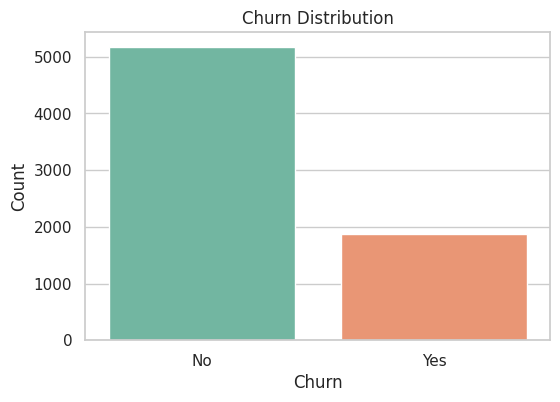

In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.savefig('../reports/figures/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Numerical Features Analysis

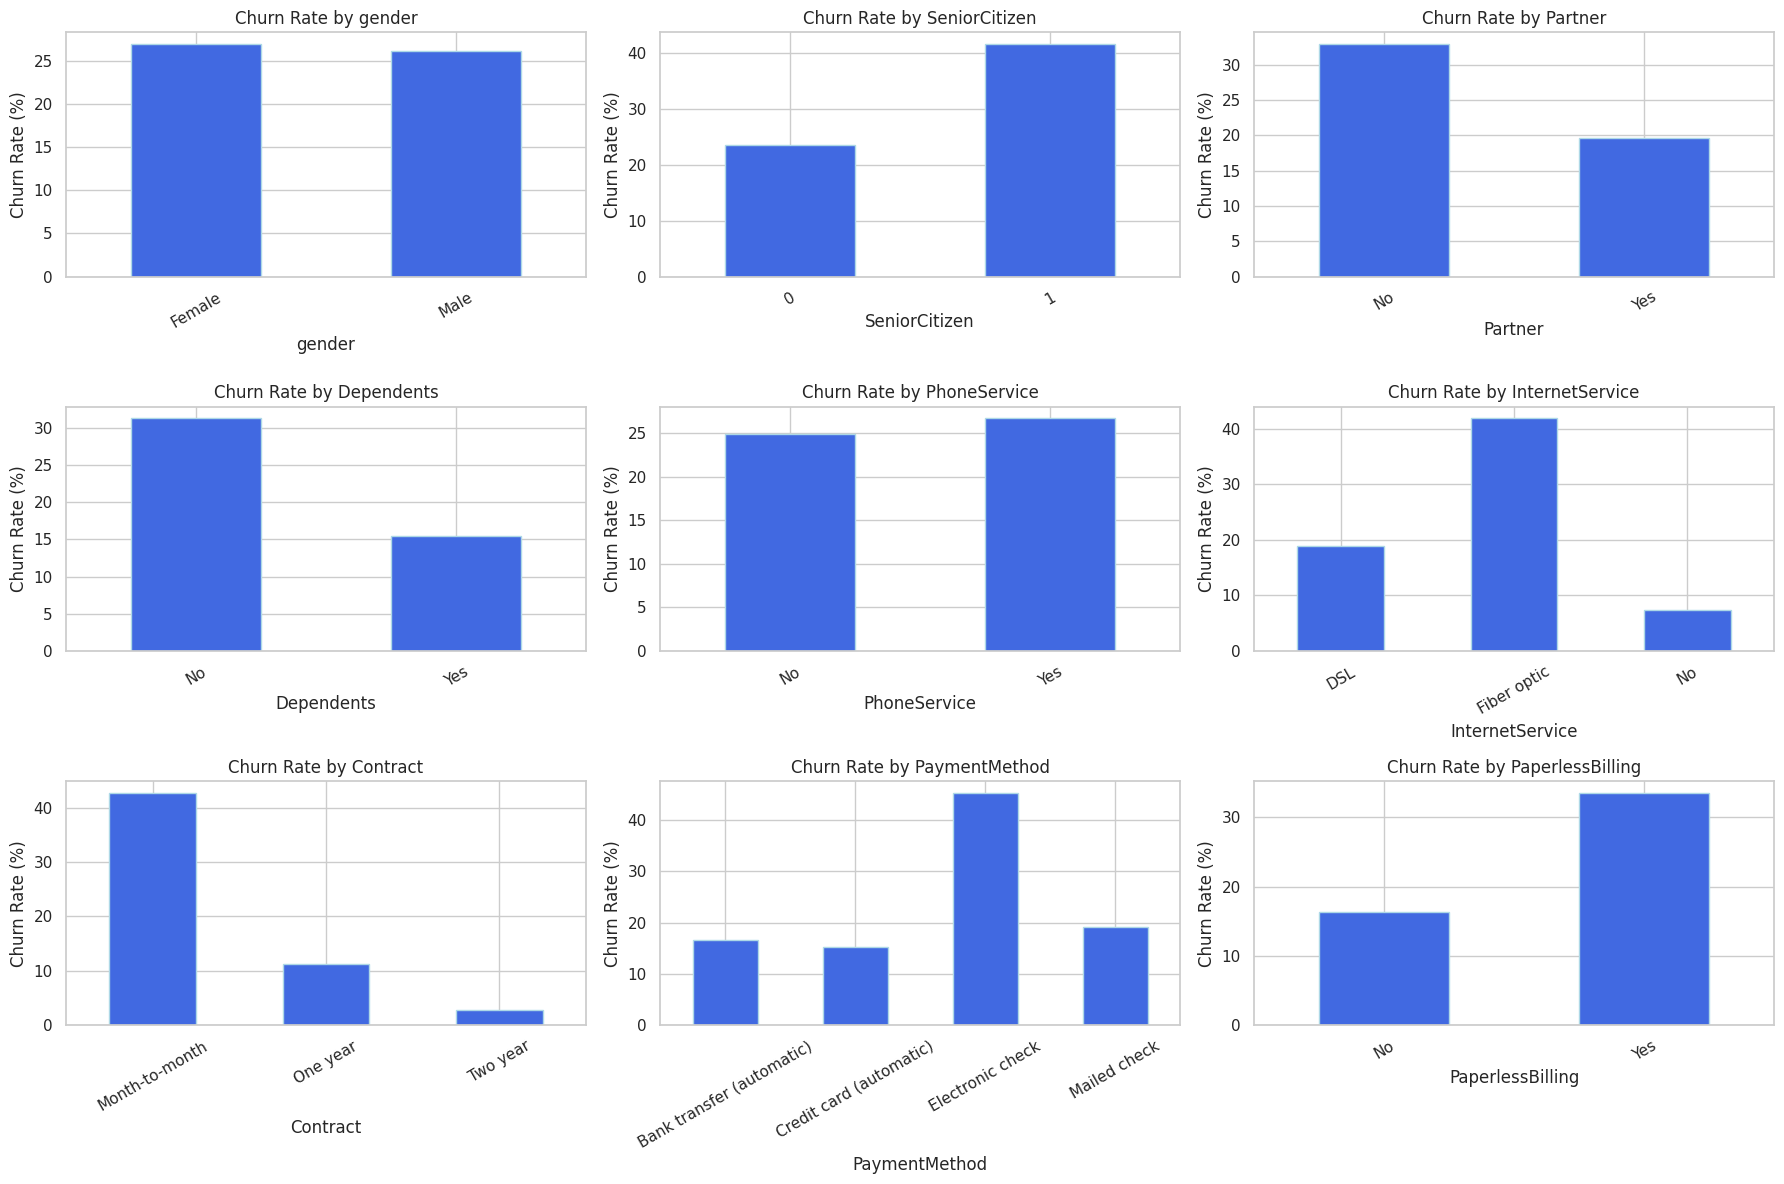

In [17]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.plot(kind='bar', ax=axes[i], color='royalblue', edgecolor='lightblue')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/figures/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlation Analysis

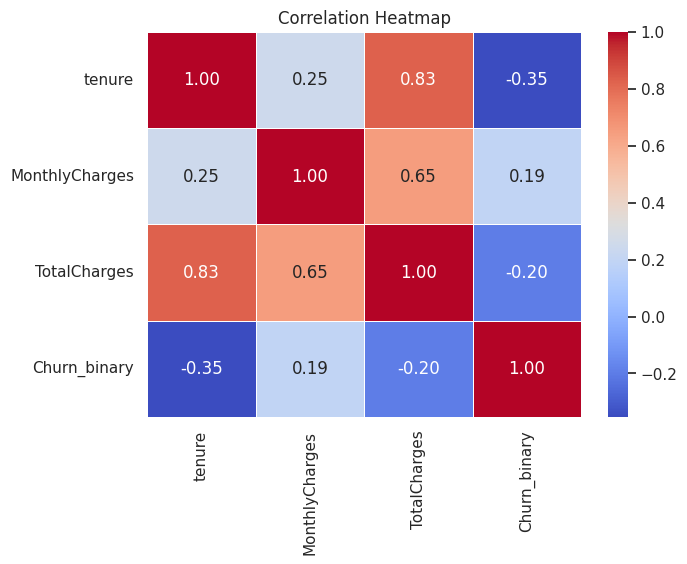

In [18]:
# Encode Churn for correlation
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusions

- Dataset contains **7,043 rows** and **21 columns** — no missing values after fixing `TotalCharges`
- **Class imbalance:** ~27% of customers churned (1,869 out of 7,043) — will need to handle this in modeling (SMOTE / class_weight)
- `TotalCharges` was stored as `object` and contained missing values — fixed by converting to numeric, filled with `0`
- **tenure → Churn: -0.35** — the longer the customer stays, the less likely they are to churn
- **MonthlyCharges → Churn: +0.19** — higher monthly charges correlate with higher churn
- **tenure & TotalCharges: 0.83** — very strong correlation, will consider dropping `TotalCharges` to avoid multicollinearity
- Customers with **month-to-month contracts** (55%) have significantly higher churn rates
- Customers without **Partner** or **Dependents** churn more often
- Next step: Feature Engineering — encode categorical variables, handle class imbalance